In [3]:
import numpy as np
import cupy as cp
import time
import pandas as pd
import matplotlib.pyplot as plt


In [4]:
from functools import wraps

def time_logger(func):
    """Декоратор, засекает время выполнения функции.
      Каждая функция выполняется 10 раз, после чего считается среднее время выполнения
    """
    @wraps(func)
    def wrapper(*args, **kwargs):
        avg_time = 0 # Среднее время выполнения
        k = 10 # количество выполнеий
        for i in range(k):
          start_time = time.time()  # Время начала
          result = func(*args, **kwargs)  # Запуск функции
          end_time = time.time()  # Время окончания

          execution_time = end_time - start_time
          avg_time += execution_time
        print(f"Среднее время выполнения: {avg_time/k:.6f} секунд")
        return result, avg_time
    return wrapper


In [5]:
def addToTable(df, n_val, c_val, column):
  df[column] = [n_val, c_val]
  return df.copy()

In [6]:
def tableGrathOut(arr_n, arr_c, arr_val):
  df_timeTable = pd.DataFrame({}, index=['numpy time (sec.)','cupy time (sec.)'])
  for index, value in enumerate(arr_val):
    df_timeTable = addToTable(df_timeTable, arr_n[index], arr_c[index], value)
  print('Таблица времени работы двух фреймворков:')
  print(df_timeTable)
  # Данные для линии X
  x = arr_val
  # Данные для линий по Y
  y1 = arr_n
  y2 = arr_c

  xlabl = 'Размерность'
  ylabl = 'Время выполнения в сек.'
  # Построение графиков
  plt.plot(x, y1, label='numpy time', color='blue', linewidth=2)
  plt.plot(x, y2, label='cupy time', color='red', linewidth=2)

  plt.title('График времени работы двух фреймворков')
  plt.xlabel(xlabl)
  plt.ylabel(ylabl)
  plt.legend()
  plt.grid(True)

  # Вывод графика
  plt.show()

  # по отдельности

  # Создание сетки: 1 строка, 2 столбца
  fig, (ax1, ax2) = plt.subplots(1, 2)

  # Первый график
  ax1.plot(x, y1, color='blue')
  ax1.set_title('numpy time')
  ax1.set_xlabel(xlabl)
  ax1.set_ylabel(ylabl)

  # Второй график
  ax2.plot(x, y2, color='red')
  ax2.set_title('cupy time')
  ax2.set_xlabel(xlabl)
  ax2.set_ylabel(ylabl)

  # Настройка расстояния между графиками
  plt.tight_layout()
  plt.show()


## Часть 2.


### Задание.

Реализовать небольшую свёрточную нейронную сеть для задачи бинарной классификации, которая может проводит вычисления и обучаться как на cpu (с использованием numpy), так и на gpu (с использованием numba).

![Пример простейшей нейронной сети](images/convolution-01.jpg.webp)

In [7]:
import torch
from torch import nn
import cv2
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tqdm import tqdm
from numba import cuda, njit, jit, prange
import numba
import os
import glob
from PIL import Image

def show_plt_img(img):
  plt.imshow(img)
  plt.show()
# для загрузки из кротковременной памяти
contentImgPath = '/content/cute-curious-gray-and-white-kitten-in-a-long-shot-photo.jpg'


In [8]:
import kagglehub

# Download latest version
path_dogs_and_cats = kagglehub.dataset_download("aleemaparakatta/cats-and-dogs-mini-dataset")

print("Path to dataset files:", path_dogs_and_cats)

100%|██████████| 21.9M/21.9M [00:01<00:00, 19.9MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/aleemaparakatta/cats-and-dogs-mini-dataset/versions/1


In [9]:
path_to_dogs = path_dogs_and_cats+'/dogs_set'
path_to_cats = path_dogs_and_cats+'/cats_set'
contentImgPath = path_to_cats+'/cat.4001.jpg'

Импортируется картинка

Type of image_BGR is   : <class 'numpy.ndarray'>
Shape of new is  : (128, 128, 3)


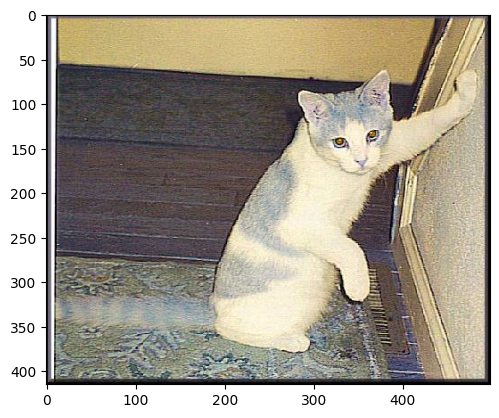

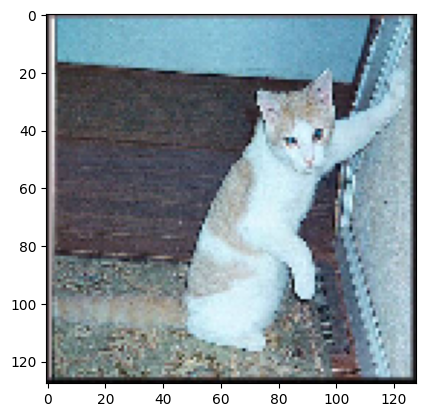

In [10]:
image_BGR = cv2.imread(contentImgPath)

im = cv2.resize(image_BGR, (128, 128), interpolation=cv2.INTER_LINEAR)
img = np.array(im)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


print('Type of image_BGR is   :', type(image_BGR))
print('Shape of new is  :', img.shape)
show_plt_img(image_BGR)
show_plt_img(img)

array([[[ 54,  45,  47],
        [125, 111, 124],
        [142, 118, 120],
        ...,
        [101,  90, 102],
        [ 95,  87,  95],
        [ 39,  35,  39]],

       [[ 55,  46,  46],
        [153, 142, 150],
        [175, 165, 164],
        ...,
        [136, 155, 168],
        [106, 113, 123],
        [ 28,  28,  32]],

       [[ 52,  46,  42],
        [177, 168, 171],
        [249, 249, 246],
        ...,
        [136, 186, 204],
        [118, 138, 149],
        [ 21,  21,  26]],

       ...,

       [[ 55,  42,  50],
        [178, 166, 173],
        [ 12,  23,  23],
        ...,
        [165, 183, 190],
        [118, 125, 132],
        [ 27,  28,  30]],

       [[ 55,  49,  55],
        [ 99,  86,  95],
        [ 27,  37,  38],
        ...,
        [ 66,  72,  79],
        [ 68,  72,  76],
        [ 26,  27,  28]],

       [[  9,  11,  12],
        [ 17,   9,  13],
        [  0,   5,   5],
        ...,
        [ 12,  10,  16],
        [  7,   8,   8],
        [  3,   4,   3]]], dtype=uint8)
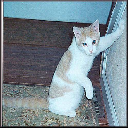

In [11]:
img

In [12]:
import torchvision.transforms as transforms


In [13]:
img = Image.open(contentImgPath).convert('L').resize((128, 128))
arr = np.asarray(img, dtype=np.float32) / 255.0
img_float = arr[None, None, :, :]

In [14]:
img_float.shape

(1, 1, 128, 128)

In [17]:
class BaseLayer(nn.Module):
    ''' класс `BaseLayer`, от которого будут наследоваться слои для вашей NN '''
    def __init__(self, **kwargs):
        super(BaseLayer, self).__init__()

    def forward(self, X):
        """Прямой проход, возвращает выход и кэш активаций с выводом среднего времени"""
        pass

    def forward_no_Time(self, X):
        """Прямой проход, возвращает выход и кэш активаций"""
        pass
    def update(self, grad, lr):
        pass

    def state_dict(self, grad, lr):
        """Настройки слоя"""
        return {}
    def load_state_dict(self, grad, lr):
        """Загрузить слоя"""
        pass

    def backward(self, dL_dy, cache):
        """Обратный проход, возвращает градиенты и dL_dx, с выводом среднего времени"""
        pass

    def backward_no_Time(self, dL_dy, cache):
        """Обратный проход, возвращает градиенты и dL_dx"""
        pass

In [18]:
bl = BaseLayer()

In [19]:
@njit
def numba_matrix_multipl(x, y):
      return x * y

@njit
def sum_matrix(x):
    '''
    sum по axis 1, 2, 3
    '''
    n0 = x.shape[0]
    res = np.zeros(n0)
    for i in range(n0):
        res[i] = np.sum(x[i, :, :, :])
    return res
    # return np.sum(x, axis=(1, 2, 3))


In [20]:
# Проверка методов sum по axis 1, 2, 3
print(np.sum(img_float, axis=(1, 2, 3)), sum_matrix(img_float))

[8547.769] [8547.56640625]


In [21]:
@njit
def conv_forward_njit(X, W, bias, pad, stride, xp):
  n, c, image_height, image_width = X.shape
  out_chanels, _, kernel_height, kernel_width = W.shape
  h_pad = image_height + 2 * pad
  w_pad = image_width + 2 * pad
  h_out = (h_pad - kernel_height) // stride + 1
  w_out = (w_pad - kernel_width) // stride + 1
  output = np.zeros((n, out_chanels, h_out, w_out), dtype=X.dtype)
  for i in prange(h_out):
    for j in prange(w_out):
      strideI = i*stride
      strideJ = j*stride
      patch = xp[:, :, strideI : strideI + kernel_height,
                  strideJ : strideJ + kernel_width]
      for oc in prange(out_chanels):
        multipl = numba_matrix_multipl(patch, W[oc : oc + 1, :, :, :])
        # (njit) не поддерживает передачу кортежа осей (tuple) в функцию np.sum(axis=...), поэтому через цикл
        output[:, oc, i, j] = sum_matrix(multipl)
  output += bias[None, :, None, None]
  return output

@njit
def conv_forward_njit_part(i, output, out_chanels, W, w_out, kernel_height, kernel_width, stride, xp):

  for j in prange(w_out):
    strideI = i*stride
    strideJ = j*stride
    patch = xp[:, :, strideI : strideI + kernel_height,
                strideJ : strideJ + kernel_width]
    for oc in prange(out_chanels):
      multipl = numba_matrix_multipl(patch, W[oc : oc + 1, :, :, :])
      # (njit) не поддерживает передачу кортежа осей (tuple) в функцию np.sum(axis=...), поэтому через цикл
      output[:, oc, i, j] = sum_matrix(multipl)

  return output

@njit
def conv_backward_njit(Y, cacheX, W, pad, stride, xp):
  n, c, image_height, image_width = cacheX.shape
  out_chanels, _, kernel_height, kernel_width = W.shape
  h_pad = image_height + 2 * pad
  w_pad = image_width + 2 * pad
  dXp = np.zeros_like(xp)
  dW = np.zeros_like(W)
  db = np.zeros_like(W[:, 0, 0, 0])
  h_out, w_out = Y.shape[2], Y.shape[3]

  for i in range(h_out):
    for j in range(w_out):
      strideI = i*stride
      strideJ = j*stride
      patch = xp[:, :, strideI : strideI + kernel_height,
                  strideJ : strideJ + kernel_width]
      for oc in range(out_chanels):
        dW[oc] += np.sum(patch * (Y[:, oc, i, j])[:, None, None, None], axis=0)
      for n_i in range(n):
        for oc in range(out_chanels):
          dXp[n_i, :, strideI : strideI + kernel_height,
                  strideJ : strideJ + kernel_width] += W[oc] + Y[n_i, oc, i, j]
  for oc in range(out_chanels):
    db[oc] = np.sum(Y[:, oc, :, :])

  if pad >0:
    dX = dXp[:, :, pad:-pad, pad:-pad]
  else:
    dX = dXp
  return dX, dW/n, db/n


# Conv2d

In [22]:
class Conv2d_layer(BaseLayer):
    # инициализирует основные параметры свёртки
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding = 1, bias = True, isDevice=False, checkMethod = False):
        '''
        Args:
            in_channels (int): Number of input channels.
            out_channels (int): Number of output channels.
            kernel_size (int or tuple[int, int]): Size of the convolutional kernel.
            stride (int, optional): Stride value for the convolution operation. Default is 1.
            isDevice (bool): compute with numba
            check_mmethod (bool): compute with simple kernel
        '''
        super(Conv2d_layer, self).__init__()
        self.rng = np.random.RandomState(42)
        # количество каналов на входе свёрточного слоя. Для RGB будет = 3
        self.in_channels = in_channels
        # количество каналов на выходе свёрточного слоя. Для RGB будет = 3
        self.out_channels = out_channels
        self.checkMethod = checkMethod
        # размер ядра свёртки, если = 3, то ядро свёртки будет размером 3x3
        if isinstance(kernel_size, int):
          self.kernel_size = kernel_size
        elif isinstance(kernel_size, tuple) and len(kernel_size) == 1:
          self.kernel_size = kernel_size[0]
        # Шаг свёртки
        K = self.kernel_size
        self.kernels = kernelMatrix = np.ones(
            (out_channels, in_channels, K, K)
          ) if self.checkMethod else self.rng.rand(
              out_channels, in_channels, K, K
          ).astype(np.float32) * np.sqrt(2.0 / (in_channels * K**2))
        self.stride = stride
        self.padding = padding
        if checkMethod == False:
          self.bias = np.array(self.rng.uniform(- 0.5, 0.5, size=out_channels), dtype=np.float32)
        else:
          self.bias = np.zeros((out_channels,), dtype=np.float32)

        self.isDevice = isDevice

    def cross_correlation(self, X):
      W = self.kernels
      pad = self.padding
      stride = self.stride
      n, c, image_height, image_width = X.shape
      out_chanels, _, kernel_height, kernel_width = W.shape
      h_pad = image_height + 2 * pad
      w_pad = image_width + 2 * pad
      xp = np.pad(X, ((0,0),(0,0),(pad, pad),(pad, pad)), mode='constant')
      h_out = (h_pad - kernel_height) // stride + 1
      w_out = (w_pad - kernel_width) // stride + 1
      output = np.zeros((n, out_chanels, h_out, w_out), dtype=X.dtype)
      for i in tqdm(range(h_out)):
        for j in range(w_out):
          strideI = i*stride
          strideJ = j*stride
          patch = xp[:, :, strideI : strideI + kernel_height,
                     strideJ : strideJ + kernel_width]
          for oc in range(out_chanels):

            output[:, oc, i, j] = np.sum(patch * W[oc : oc + 1, :, :, :], axis=(1, 2, 3))
      output += self.bias[None, :, None, None]
      print()
      return output

    def cross_correlation_backw(self, Y, cacheX):
      W = self.kernels
      pad = self.padding
      stride = self.stride
      n, c, image_height, image_width = cacheX.shape
      out_chanels, _, kernel_height, kernel_width = W.shape
      h_pad = image_height + 2 * pad
      w_pad = image_width + 2 * pad
      xp = np.pad(cacheX, ((0,0),(0,0),(pad, pad),(pad, pad)), mode='constant')
      dXp = np.zeros_like(xp)
      dW = np.zeros_like(W)
      db = np.zeros_like(W[:, 0, 0, 0])
      h_out, w_out = Y.shape[2], Y.shape[3]

      for i in tqdm(range(h_out)):
        for j in range(w_out):
          strideI = i*stride
          strideJ = j*stride
          patch = xp[:, :, strideI : strideI + kernel_height,
                     strideJ : strideJ + kernel_width]
          for oc in range(out_chanels):
            dW[oc] += np.sum(patch * (Y[:, oc, i, j])[:, None, None, None], axis=0)
          for n_i in range(n):
            for oc in range(out_chanels):
              dXp[n_i, :, strideI : strideI + kernel_height,
                     strideJ : strideJ + kernel_width] += W[oc] + Y[n_i, oc, i, j]
      for oc in range(out_chanels):
        db[oc] = np.sum(Y[:, oc, :, :])

      if pad >0:
        dX = dXp[:, :, pad:-pad, pad:-pad]
      else:
        dX = dXp
      print()
      return dX, dW/n, db/n
    def cross_correlation_forw_device(self, X):
      # njit не поддерживает функцию pad, поэтому вчисления производятся здесь
      pad = self.padding
      xp = np.pad(X, ((0,0),(0,0),(pad, pad),(pad, pad)), mode='constant')
      return conv_forward_njit(X, self.kernels, self.bias, pad, self.stride, xp)

    def cross_correlation_backw_device(self, Y, cacheX):
      # njit не поддерживает функцию pad, поэтому вчисления производятся здесь
      pad = self.padding
      xp = np.pad(cacheX, ((0,0),(0,0),(pad, pad),(pad, pad)), mode='constant')
      return conv_backward_njit(Y, cacheX, self.kernels, pad, self.stride, xp)

    def forward_func(self, X):
      cross_correlation_func = self.cross_correlation if self.isDevice ==False else self.cross_correlation_forw_device
      output = cross_correlation_func(X)
      cache = (X, output)
      return output, cache

    def backward_func(self, dY, cache):
      X, _ = cache
      cross_correlation_func = self.cross_correlation_backw if self.isDevice ==False else self.cross_correlation_backw_device
      dX, dW, db = cross_correlation_func(dY, X)
      grad = {'weights': dW, 'bias': db}
      return dX, grad

    @time_logger
    def forward(self, X):
      return self.forward_func(X)

    def forward_no_Time(self, X):
      return self.forward_func(X)

    @time_logger
    def backward(self, X, cache):
      return self.backward_func(X, cache)

    def backward_no_Time(self, X, cache):
      return self.backward_func(X, cache)

    def update(self, grad, lr):
      self.kernels -= lr * grad['weights']

    def state_dict(self):
      return {
        'in_channels': self.in_channels,
        'out_channels': self.out_channels,
        'stride': self.stride,
        'kernel_size': self.kernel_size,
        'weights': self.kernels,
        'padding': self.padding,
        'bias': self.bias,
        'isDevice': self.isDevice
      }

    def load_state_dict(self, state):
      self.in_channels = state['in_channels']
      self.out_channels = state['out_channels']
      self.kernel_size = state['kernel_size']
      self.stride = state['stride']
      self.kernels = state['weights']
      self.isDevice = state['isDevice']
      self.bias = state['bias']
      self.padding = state['padding']

Conv2D на CPU

In [23]:
img_float.shape

(1, 1, 128, 128)

In [24]:
conv2d_cpu_layer = Conv2d_layer(in_channels=1, out_channels=11, kernel_size=3)
print("--------------froward Conv2d----------------")
(conv_cpu, cache_conv_cpu), _ = conv2d_cpu_layer.forward(img_float)
print("--------------backward Conv2d----------------")
(conv_cpu_bck, grad_conv_cpu), _ = conv2d_cpu_layer.backward(conv_cpu, cache_conv_cpu)
print(f"Input shape: {img_float.shape}")
print(f"output shape: {conv_cpu.shape}")
print(f"backward shape: {conv_cpu_bck.shape}")



--------------froward Conv2d----------------


100%|██████████| 128/128 [00:01<00:00, 107.40it/s]


100%|██████████| 128/128 [00:01<00:00, 98.56it/s]


100%|██████████| 128/128 [00:01<00:00, 100.69it/s]


100%|██████████| 128/128 [00:01<00:00, 98.30it/s]


...

100%|██████████| 128/128 [00:03<00:00, 39.31it/s]


100%|██████████| 128/128 [00:02<00:00, 43.95it/s]


100%|██████████| 128/128 [00:02<00:00, 49.49it/s]


100%|██████████| 128/128 [00:02<00:00, 47.72it/s]


Среднее время выполнения: 2.805244 секунд
Input shape: (1, 1, 128, 128)
output shape: (1, 11, 128, 128)
backward shape: (1, 1, 128, 128)


In [ ]:
conv_cpu[0][1]

array([[-0.23332544, -0.0588145 , -0.02532363, ..., -0.04766351,
        -0.1580219 , -0.28025162],
       [-0.0169602 ,  0.2941267 ,  0.4129454 , ...,  0.40784502,
         0.15486145, -0.11565039],
       [ 0.11774397,  0.49861014,  0.65567267, ...,  0.6782955 ,
         0.3094738 , -0.03476158],
       ...,
       [ 0.09725899,  0.22750682,  0.5286984 , ...,  0.6110097 ,
         0.32689536, -0.0252592 ],
       [-0.02626657,  0.03778213,  0.23841476, ...,  0.27340662,
         0.06458879, -0.13594052],
       [-0.24929109, -0.22344832, -0.15559658, ..., -0.15410489,
        -0.24134305, -0.31908906]], dtype=float32)

In [ ]:
conv_cpu_bck[0][0]

array([[ 29.640907,  50.36295 ,  58.414295, ...,  56.060482,  43.732506,
         23.626955],
       [ 52.561996,  89.197395, 104.10667 , ...,  99.77486 ,  76.80326 ,
         41.398327],
       [ 63.572506, 108.663765, 128.05516 , ..., 122.40275 ,  92.056206,
         48.441864],
       ...,
       [ 51.885944,  86.07628 ,  94.37133 , ..., 109.694214,  82.62208 ,
         44.043198],
       [ 38.48683 ,  62.046116,  65.99772 , ...,  75.72655 ,  59.090183,
         32.631424],
       [ 20.60595 ,  32.06888 ,  33.281403, ...,  37.62337 ,  30.269379,
         17.007257]], dtype=float32)

Conv2D с Numba

In [ ]:
conv2d_numba_layer = Conv2d_layer(in_channels=1, out_channels=11, kernel_size=3, isDevice=True)
print("--------------froward Conv2d----------------")
(conv_numba, cache_conv_numba), _ = conv2d_numba_layer.forward(img_float)
print("--------------backward Conv2d----------------")
(conv_numba_bck, grad_conv_numba), _ = conv2d_numba_layer.backward(conv_numba, cache_conv_numba)
print(conv_numba_bck.shape)
print(f"Input shape: {img_float.shape}")
print(f"output shape: {conv_numba.shape}")
print(f"backward shape: {conv_numba_bck.shape}")


--------------froward Conv2d----------------
Среднее время выполнения: 0.240639 секунд
--------------backward Conv2d----------------
Среднее время выполнения: 0.503999 секунд
(1, 1, 128, 128)
Input shape: (1, 1, 128, 128)
output shape: (1, 11, 128, 128)
backward shape: (1, 1, 128, 128)


In [ ]:
conv_numba[0][1]

array([[-0.23332544, -0.0588145 , -0.02532363, ..., -0.04766351,
        -0.1580219 , -0.28025162],
       [-0.0169602 ,  0.2941267 ,  0.4129454 , ...,  0.40784502,
         0.15486145, -0.11565039],
       [ 0.11774397,  0.49861014,  0.65567267, ...,  0.6782955 ,
         0.3094738 , -0.03476158],
       ...,
       [ 0.09725899,  0.22750682,  0.5286984 , ...,  0.6110097 ,
         0.32689536, -0.0252592 ],
       [-0.02626657,  0.03778213,  0.23841476, ...,  0.27340662,
         0.06458879, -0.13594052],
       [-0.24929109, -0.22344832, -0.15559658, ..., -0.15410489,
        -0.24134305, -0.31908906]], dtype=float32)

In [ ]:
conv_numba_bck[0][0]

array([[ 29.640907,  50.36295 ,  58.414295, ...,  56.060482,  43.732506,
         23.626955],
       [ 52.561996,  89.197395, 104.10667 , ...,  99.77486 ,  76.80326 ,
         41.398327],
       [ 63.572506, 108.663765, 128.05516 , ..., 122.40275 ,  92.056206,
         48.441864],
       ...,
       [ 51.885944,  86.07628 ,  94.37133 , ..., 109.694214,  82.62208 ,
         44.043198],
       [ 38.48683 ,  62.046116,  65.99772 , ...,  75.72655 ,  59.090183,
         32.631424],
       [ 20.60595 ,  32.06888 ,  33.281403, ...,  37.62337 ,  30.269379,
         17.007257]], dtype=float32)

Выходные данные совпадают у numba и numpy



проверка на небольших данных

In [ ]:
# данные для проверки на небольших данных
input_image = np.asarray([
    [0, 0, 0, 0],
    [0, 1, 1, 0],
    [0, 1, 1, 0],
    [0, 0, 0, 0],
], dtype=np.float32)
input_test_array = input_image[None, None, :, :]
print(input_test_array)

[[[[0. 0. 0. 0.]
   [0. 1. 1. 0.]
   [0. 1. 1. 0.]
   [0. 0. 0. 0.]]]]


In [60]:
def check_layers_forward_backward(test_array, layer):
  # Проверка на небольших данных
  print('---------input array---------')
  print(test_array.shape,'\n', test_array)
  print('---------forward---------')
  (layer_example, layer_cache), _ = layer.forward(test_array)
  print(layer_example.shape, '\n', layer_example)
  print('---------backward---------')
  (layer_example_bck, grad_layer), _ = layer.backward(layer_example, layer_cache)
  print(layer_example_bck.shape, '\n', layer_example_bck)


In [ ]:
conv2d_ex = Conv2d_layer(in_channels=1, out_channels=2, kernel_size=3, padding = 0, isDevice=True, checkMethod=True)
check_layers_forward_backward(input_test_array, conv2d_ex)

---------input array---------
(1, 1, 4, 4) 
 [[[[0. 0. 0. 0.]
   [0. 1. 1. 0.]
   [0. 1. 1. 0.]
   [0. 0. 0. 0.]]]]
---------forward---------
Среднее время выполнения: 0.000059 секунд
(1, 2, 2, 2) 
 [[[[4. 4.]
   [4. 4.]]

  [[4. 4.]
   [4. 4.]]]]
---------backward---------
Среднее время выполнения: 0.000065 секунд
(1, 1, 4, 4) 
 [[[[10. 20. 20. 10.]
   [20. 40. 40. 20.]
   [20. 40. 40. 20.]
   [10. 20. 20. 10.]]]]


In [ ]:
# сравнение с torch реализацией
conv_layer_nn = torch.nn.Conv2d(1,2,3,1,1 )
conv_layer_nn(torch.from_numpy(input_test_array))

tensor([[[[-0.2512, -0.2659, -0.2403, -0.2256],
          [-0.0769,  0.0942, -0.3012, -0.4722],
          [ 0.0177, -0.0252, -0.3656, -0.3227],
          [-0.1566, -0.3853, -0.3048, -0.0761]],

         [[ 0.5721,  0.8374,  0.5753,  0.3100],
          [ 0.6322,  0.9394,  0.9088,  0.6015],
          [ 0.5889,  0.2978,  0.4455,  0.7366],
          [ 0.5288,  0.1958,  0.1120,  0.4450]]]],
       grad_fn=<ConvolutionBackward0>)

**Вывод:**

С использованием numba скорость вычислений выросла в 36 раз (на изображении 128*128 numpy = 1.44 сек, numba = 0.04)

backward метод с использованием numba увеличил скорость вычислений в 22 раза (numpy = 2.93 сек, numba = 0.13)

Прирост forward метода получилось получить за счет Оборачивания numpy функции всех вычислений  в декоратор njit (для метода sum по axis с tuples использовалась отдельная функция, написанная для njit), а для backward метода за счет оборачивания всего метода в декоратор njit

# ReLU

In [25]:
@jit(parallel=True,fastmath=True)
def numba_maximum(x):
      return np.maximum(0,x)

@jit(parallel=True,fastmath=True)
def numba_maximum_backward(x, input_matrix):
      return (x > 0) * input_matrix

In [26]:
class ReLU_layer(BaseLayer):
    def __init__(self, isDevice=False, checkMethod = False):
        super(ReLU_layer, self).__init__()
        self.checkMethod = checkMethod
        self.isDevice = isDevice

    def forward_func(self, x):
      self.x = x
      if self.isDevice:
        return numba_maximum(x), self.x
      else:
        return np.maximum(0,x), self.x

    def backward_func(self, input_matrix, cahce):
      x = cahce
      if self.isDevice:
        return numba_maximum_backward(x, input_matrix), {}
      else:
        return (x > 0) * input_matrix, {}

    @time_logger
    def forward(self, X):
      return self.forward_func(X)

    def forward_no_Time(self, X):
      return self.forward_func(X)

    @time_logger
    def backward(self, X, cahce):
      return self.backward_func(X, cahce)

    def backward_no_Time(self, X, cahce):
      return self.backward_func(X, cahce)

    def state_dict(self):
      return {
        'isDevice': self.isDevice
      }
    def load_state_dict(self, state):
      self.isDevice = state['isDevice']

ReLU_layer на CPU

In [ ]:
cpu_relu_layer = ReLU_layer()
(relu_cpu, relu_cpu_cache), _ = cpu_relu_layer.forward(img_float)
print(relu_cpu)
print(f"Input shape: {img_float.shape}")
print(f"output shape: {relu_cpu.shape}")

(relu_cpu_bckw, grad_relu_cpu), _ = cpu_relu_layer.backward(relu_cpu, relu_cpu_cache)
print(relu_cpu_bckw)
print(f"Input shape: {img_float.shape}")
print(f"output shape: {relu_cpu.shape}")

Среднее время выполнения: 0.000172 секунд
[[[[0.18039216 0.34901962 0.3137255  ... 0.29411766 0.2901961
    0.13725491]
   [0.22352941 0.627451   0.6784314  ... 0.6039216  0.45490196
    0.14901961]
   [0.20784314 0.74509805 0.8980392  ... 0.7137255  0.53333336
    0.10588235]
   ...
   [0.20784314 0.74509805 0.5176471  ... 0.77254903 0.5294118
    0.11372549]
   [0.22745098 0.43529412 0.2509804  ... 0.36078432 0.32156864
    0.12941177]
   [0.08627451 0.10980392 0.0627451  ... 0.07843138 0.09019608
    0.05490196]]]]
Input shape: (1, 1, 128, 128)
output shape: (1, 1, 128, 128)
Среднее время выполнения: 0.000029 секунд
[[[[0.18039216 0.34901962 0.3137255  ... 0.29411766 0.2901961
    0.13725491]
   [0.22352941 0.627451   0.6784314  ... 0.6039216  0.45490196
    0.14901961]
   [0.20784314 0.74509805 0.8980392  ... 0.7137255  0.53333336
    0.10588235]
   ...
   [0.20784314 0.74509805 0.5176471  ... 0.77254903 0.5294118
    0.11372549]
   [0.22745098 0.43529412 0.2509804  ... 0.36078432 

ReLU_layer с Numba

In [ ]:
relu_numba_layer = ReLU_layer(isDevice=True)
(relu_numba, cache_relu_numba), _ = relu_numba_layer.forward(img_float)
print(relu_numba)
print(f"Input shape: {img_float.shape}")
print(f"Output shape: {relu_numba.shape}")

(relu_numba_bckw, grad_relu_numba), _ = relu_numba_layer.backward(relu_numba, cache_relu_numba)
print(relu_numba_bckw)
print(f"Input shape: {img_float.shape}")
print(f"output shape: {relu_numba_bckw.shape}")

Среднее время выполнения: 0.000183 секунд
[[[[0.18039216 0.34901962 0.3137255  ... 0.29411766 0.2901961
    0.13725491]
   [0.22352941 0.627451   0.6784314  ... 0.6039216  0.45490196
    0.14901961]
   [0.20784314 0.74509805 0.8980392  ... 0.7137255  0.53333336
    0.10588235]
   ...
   [0.20784314 0.74509805 0.5176471  ... 0.77254903 0.5294118
    0.11372549]
   [0.22745098 0.43529412 0.2509804  ... 0.36078432 0.32156864
    0.12941177]
   [0.08627451 0.10980392 0.0627451  ... 0.07843138 0.09019608
    0.05490196]]]]
Input shape: (1, 1, 128, 128)
Output shape: (1, 1, 128, 128)
Среднее время выполнения: 0.000059 секунд
[[[[0.18039216 0.34901962 0.3137255  ... 0.29411766 0.2901961
    0.13725491]
   [0.22352941 0.627451   0.6784314  ... 0.6039216  0.45490196
    0.14901961]
   [0.20784314 0.74509805 0.8980392  ... 0.7137255  0.53333336
    0.10588235]
   ...
   [0.20784314 0.74509805 0.5176471  ... 0.77254903 0.5294118
    0.11372549]
   [0.22745098 0.43529412 0.2509804  ... 0.36078432 

Выходные данные совпадают у numba и numpy



In [ ]:
# данные для проверки на небольших данных
input_image_relu = np.asarray([
    [-1, 0, 0, 0],
    [0, 1, 1, 0],
    [0, 1, 1, 0],
    [0, 0, 0, -1],
], dtype=np.float32)
input_test_array_relu = input_image_relu[None, None, :, :]
print(input_test_array_relu)

[[[[-1.  0.  0.  0.]
   [ 0.  1.  1.  0.]
   [ 0.  1.  1.  0.]
   [ 0.  0.  0. -1.]]]]


In [ ]:
relu_l_ex = ReLU_layer(isDevice=True, checkMethod=True)
check_layers_forward_backward(input_test_array_relu, relu_l_ex)

---------input array---------
(1, 1, 4, 4) 
 [[[[-1.  0.  0.  0.]
   [ 0.  1.  1.  0.]
   [ 0.  1.  1.  0.]
   [ 0.  0.  0. -1.]]]]
---------forward---------
Среднее время выполнения: 0.000100 секунд
(1, 1, 4, 4) 
 [[[[0. 0. 0. 0.]
   [0. 1. 1. 0.]
   [0. 1. 1. 0.]
   [0. 0. 0. 0.]]]]
---------backward---------
Среднее время выполнения: 0.000097 секунд
(1, 1, 4, 4) 
 [[[[0. 0. 0. 0.]
   [0. 1. 1. 0.]
   [0. 1. 1. 0.]
   [0. 0. 0. 0.]]]]


Проверка оптимизации на больших размерностях

In [ ]:
arr_big_big = np.arange(250000000).reshape(5000, 5000, 10)

In [ ]:
(big_relu_numba, _), _ = ReLU_layer(isDevice=True).forward(arr_big_big)
print(big_relu_numba[0])
print(f"Input shape: {arr_big_big.shape}")
print(f"Output shape: {big_relu_numba.shape}")

Среднее время выполнения: 0.888947 секунд
[[    0     1     2 ...     7     8     9]
 [   10    11    12 ...    17    18    19]
 [   20    21    22 ...    27    28    29]
 ...
 [49970 49971 49972 ... 49977 49978 49979]
 [49980 49981 49982 ... 49987 49988 49989]
 [49990 49991 49992 ... 49997 49998 49999]]
Input shape: (5000, 5000, 10)
Output shape: (5000, 5000, 10)


In [ ]:
(big_relu_cpu, _), _ = ReLU_layer(isDevice=False).forward(arr_big_big)
print(big_relu_cpu[0])
print(f"Input shape: {arr_big_big.shape}")
print(f"Output shape: {big_relu_cpu.shape}")

Среднее время выполнения: 0.826875 секунд
[[    0     1     2 ...     7     8     9]
 [   10    11    12 ...    17    18    19]
 [   20    21    22 ...    27    28    29]
 ...
 [49970 49971 49972 ... 49977 49978 49979]
 [49980 49981 49982 ... 49987 49988 49989]
 [49990 49991 49992 ... 49997 49998 49999]]
Input shape: (5000, 5000, 10)
Output shape: (5000, 5000, 10)


In [ ]:
del arr_big_big
del big_relu_numba
del big_relu_cpu

**Вывод:**

С использованием numba скорость вычислений Увеличить не удалось, методы работают одинаково быстро (на размере 5000x5000x10 numpy  = 1.05 сек, numba = 0.95 сек)


# LinearLayer

In [155]:
@njit
def numba_mean(x):
  return np.sum(x, axis=0) / x.shape[0]
  # return np.mean(x, axis=0)

@njit
def batched_matmul(x, weights, bias=None):
    """
    Performs batched matrix multiplication for 3D tensors x 2D.
    x: (batch, n, h, m)
    weights: (m, p)
    bias: (1, p)
    Returns: (batch, n, p)
    """
    if (x.ndim == 2):
      dot_x =  np.dot(x.astype(np.float32), weights.astype(np.float32))
      return dot_x if bias==None else dot_x + bias

    batch, n, h, m = x.shape
    _, p = weights.shape
    # предполагаем, что у нас поддерживается только один батч

    R = np.empty((batch, n, h, p), dtype=np.float32)
    for b in prange(batch):
      C = np.empty((n, h, p), dtype=np.float32)
      # т.к. numba поддерживает матричное умножение только для 2D, перемножается для каждого батча
      for i in prange(n):
          patch = x[0][i].astype(np.float32)
          C[i] = np.dot(patch, weights.astype(np.float32))
      R[b] = C
    return R if bias==None else R + bias


In [96]:
class Linear_layer(BaseLayer):
    def __init__(self, in_features, out_features, bias=True, isDevice=False, checkMethod = False):
        super(Linear_layer, self).__init__()
        '''
        y = Ax+b
        '''
        self.in_features = in_features
        self.out_features = out_features
        self.rng = np.random.RandomState(42)
        # Случайные веса
        self.checkMethod = checkMethod
        self.weights = (np.ones((out_features, in_features)) if checkMethod else self.rng.rand(
              out_features, in_features).astype(np.float32) * np.sqrt(2.0 / (in_features)))
        # bias
        if bias and not checkMethod:
            self.bias = self.rng.uniform(- 0.5, 0.5, size=out_features)
        else:
            self.bias = np.zeros(out_features)
        self.isDevice = isDevice

    def forward_func(self, x):
      self.x = x
      if self.isDevice:

        result = batched_matmul(x.astype(np.float32), self.weights.T.astype(np.float32), self.bias.astype(np.float32))
      else:
        result = np.dot(x,  self.weights.T) + self.bias
      return result, self.x

    def backward_func(self, input_matrix, cache):
      X = cache
      if self.isDevice:
        dW = batched_matmul(input_matrix.T.astype(np.float32), X.astype(np.float32), None) / X.shape[0]
        db = numba_mean(input_matrix.astype(np.float32))
        result = batched_matmul(input_matrix.astype(np.float32), self.weights.astype(np.float32), None)
      else:
        dW = np.dot(input_matrix.T.astype(np.float32), X) / X.shape[0]
        db = np.mean(input_matrix, axis=0)
        result = np.dot(input_matrix, self.weights)
      return result, {'weights': dW, 'bias': db}

    @time_logger
    def forward(self, X):
      return self.forward_func(X)

    def forward_no_Time(self, X):
      return self.forward_func(X)

    @time_logger
    def backward(self, X, cache):
      return self.backward_func(X, cache)

    def backward_no_Time(self, X, cache):
      return self.backward_func(X, cache)

    def update(self, grad, lr):
      self.weights -= lr * grad['weights']
      self.bias -= lr * grad['bias']

    def state_dict(self):
      return {
        'in_features': self.in_features,
        'out_features': self.out_features,
        'bias': self.bias,
        'weights': self.weights,
        'isDevice': self.isDevice
      }

    def load_state_dict(self, state):
      self.in_features = state['in_features']
      self.out_features = state['out_features']
      self.bias = state['bias']
      self.weights = state['weights']
      self.isDevice = state['isDevice']

linearLayer на CPU

In [102]:
lin_cpu_layer = Linear_layer(in_features=128, out_features=256)
print("--------------froward Conv2d----------------")
(linear_cpu, linear_cpu_cache), _ = lin_cpu_layer.forward(img_float)
# print("--------------backward Conv2d----------------")
# (linear_cpu_bck, grad_linear_cpu), _ = lin_cpu_layer.backward(linear_cpu, linear_cpu_cache)
print(f"Input shape: {img_float.shape}")
print(f"output shape: {linear_cpu.shape}")
# print(f"backward shape: {linear_cpu_bck.shape}")

--------------froward Conv2d----------------
Среднее время выполнения: 0.001359 секунд
Input shape: (1, 1, 128, 128)
output shape: (1, 1, 128, 256)


In [99]:
print(linear_cpu)

[[[[2.48192253 2.44688726 2.3190425  ... 2.01977152 2.32171005
    1.88218795]
   [4.40198707 4.45500808 4.3155808  ... 4.07932919 4.35381192
    3.87955502]
   [5.12623562 5.19329463 5.07993164 ... 4.88135098 5.11573102
    4.63083107]
   ...
   [4.57465094 4.55844822 4.28856227 ... 4.08052939 4.35811162
    4.01270273]
   [2.53063295 2.4560694  2.28378912 ... 2.00529892 2.31103545
    1.90813342]
   [0.86599328 0.76419308 0.66363473 ... 0.32595402 0.61968679
    0.19517921]]]]


LinearLayer с Numba

In [ ]:
lin_layer_numba = Linear_layer(in_features=128, out_features=256, isDevice=True)
(linear_numba, linear_numba_cache), _ = lin_layer_numba.forward(img_float)
print(f"Input shape: {img_float.shape}")
print(f"Output shape: {linear_numba.shape}")


Среднее время выполнения: 0.000718 секунд
Input shape: (1, 1, 128, 128)
Output shape: (1, 1, 128, 256)


In [ ]:
print(linear_numba)

[[[[2.4819224  2.446887   2.3190427  ... 2.0197718  2.3217103
    1.882188  ]
   [4.4019876  4.455008   4.315582   ... 4.0793295  4.3538113
    3.879556  ]
   [5.1262364  5.1932945  5.079933   ... 4.881351   5.1157317
    4.6308317 ]
   ...
   [4.5746512  4.558449   4.2885623  ... 4.0805297  4.358112
    4.0127034 ]
   [2.5306332  2.4560692  2.2837892  ... 2.0052989  2.3110354
    1.9081343 ]
   [0.8659932  0.76419306 0.66363466 ... 0.32595402 0.6196867
    0.19517922]]]]


Выходные данные совпадают у numba и numpy



In [56]:
input_test_arr_2d = np.asarray([
    [-1, 0, 0, 0],
    [0, 1, 1, 0],
    [0, 1, 1, 0],
    [0, 0, 0, -1],
], dtype=np.float32)

In [63]:
linear_layer_ex = Linear_layer(in_features=4, out_features=8, isDevice=False, checkMethod=True)
check_layers_forward_backward(input_test_arr_2d, linear_layer_ex)

---------input array---------
(4, 4) 
 [[-1.  0.  0.  0.]
 [ 0.  1.  1.  0.]
 [ 0.  1.  1.  0.]
 [ 0.  0.  0. -1.]]
---------forward---------
Среднее время выполнения: 0.000043 секунд
(4, 8) 
 [[-1. -1. -1. -1. -1. -1. -1. -1.]
 [ 2.  2.  2.  2.  2.  2.  2.  2.]
 [ 2.  2.  2.  2.  2.  2.  2.  2.]
 [-1. -1. -1. -1. -1. -1. -1. -1.]]
---------backward---------
Среднее время выполнения: 0.000206 секунд
(4, 4) 
 [[-8. -8. -8. -8.]
 [16. 16. 16. 16.]
 [16. 16. 16. 16.]
 [-8. -8. -8. -8.]]


In [ ]:
# сравнение с torch
linear_nn_layer = nn.Linear(4,8)
linear_nn_layer(torch.from_numpy(input_test_arr_2d))

tensor([[-0.0270,  0.1892,  0.3148, -0.0259, -0.2071, -0.0154,  0.0032, -0.1485],
        [-0.3678, -0.7354,  0.8937,  0.1414,  0.5271, -0.5626,  0.4999, -0.5773],
        [-0.3678, -0.7354,  0.8937,  0.1414,  0.5271, -0.5626,  0.4999, -0.5773],
        [-0.1833, -0.3207,  0.5915,  0.3351,  0.2916, -0.9388,  0.5076, -0.2736]],
       grad_fn=<AddmmBackward0>)

Проверка оптимизации на больших размерностях

In [ ]:
arr_big = np.arange(27000000).reshape(1, 3000, 3000, 3)

In [ ]:
(big_linear_numba, _), _ = Linear_layer(in_features=3, out_features=11, isDevice=True).forward(arr_big)
print(big_linear_numba[0][0][0])
print(f"Input shape: {arr_big.shape}")
print(f"Output shape: {big_linear_numba.shape}")

Среднее время выполнения: 0.419895 секунд
[2.4204814  0.84775865 1.9972439  1.405277   0.06796521 1.2895695
 1.1770917  0.45883977 0.9623363  0.09394619 0.6547816 ]
Input shape: (1, 3000, 3000, 3)
Output shape: (1, 3000, 3000, 11)


In [ ]:
(big_linear_cpu, _), _ = Linear_layer(in_features=3, out_features=11, isDevice=False).forward(arr_big)
print(big_linear_numba[0][0][0])
print(f"Input shape: {arr_big.shape}")
print(f"Output shape: {big_linear_cpu.shape}")

Среднее время выполнения: 2.677334 секунд
[2.4204814  0.84775865 1.9972439  1.405277   0.06796521 1.2895695
 1.1770917  0.45883977 0.9623363  0.09394619 0.6547816 ]
Input shape: (1, 3000, 3000, 3)
Output shape: (1, 3000, 3000, 11)


In [ ]:
del arr_big
del big_linear_numba
del big_linear_cpu

**Вывод:**

С использованием numba скорость вычислений увеличилась в 5 раз (на размере 1x3000x3000x3 numpy  = 2.16 сек, numba = 0.42 сек)

Текущая реализация предполагает работу только с 2d массивами, либо с тензорами с 1 батчем

# MaxPool2D

In [29]:
@njit
def numba_get_max(x):
  return np.max(x)

@njit
def numba_maxPoolFunc(image, output_height, output_width, stride, kernel_size, output, mask):
  for i in range(output_height):
    for j in range(output_width):
      # Extract subsection (i*stride, j*stride) to ((i+1)*stride, (j+1)*stride)
      iStride = i * stride
      jStride = j * stride
      subsection = image[:, :,
        iStride : iStride + kernel_size[0],
        jStride : jStride + kernel_size[1],
      ]
      # Compute max value of the subsection and assign it to output
      output[:, :, i, j] = numba_get_max(subsection[0, 0, :, :])
      maxpos = (subsection == output[:, :, i, j][:,:,None,None])
      mask[:, :,
        iStride : iStride + kernel_size[0],
        jStride : jStride + kernel_size[1],
      ] = mask[:, :,
        iStride : iStride + kernel_size[0],
        jStride : jStride + kernel_size[1],
      ] | maxpos
  return output, mask

@njit
def numba_maxPoolFunc_back(output_height, output_width, Y, stride, kernel_size, output, mask):
  for h in range(output_height):
    for w in range(output_width):
      h_start, h_end = h * stride, h * stride + kernel_size[0]
      w_start, w_end = w * stride, w * stride + kernel_size[1]
      output[:,:,h_start : h_end, w_start : w_end] -= (mask[:,:,h_start : h_end, w_start : w_end] * Y[:,:,h:h+1,w:w+1])
  return output

In [80]:
class MaxPool2D_layer(BaseLayer):
    # инициализирует основные параметры свёртки
    def __init__(self, kernel_size, stride=1, isDevice=False, checkMethod = False):
        super(MaxPool2D_layer, self).__init__()
        # размер ядра свёртки, если = 3, то ядро свёртки будет размером 3x3
        if isinstance(kernel_size, int):
          self.kernel_size = (kernel_size, kernel_size)
        elif isinstance(kernel_size, tuple) and len(kernel_size) == 1:
          self.kernel_size = (kernel_size[0], kernel_size[0])
        # Шаг свёртки
        self.stride = stride
        self.rng = np.random.RandomState(42)
        self.isDevice = isDevice
        self.checkMethod = checkMethod
        # self.forward()

    # метод позволяет задавать весовые коэффициенты ядра свёртки
    # ниже в дочернем классе Conv2d мы его переопределим
    def set_kernel(self, kernel):
        self.kernel = kernel

    def maxPoolFunc(self, output_height, output_width, image, output, mask):
      # получение максимального значения из ядра
      for i in range(output_height):
        for j in range(output_width):
          # Extract subsection (i*stride, j*stride) to ((i+1)*stride, (j+1)*stride)
          iStride = i * self.stride
          jStride = j * self.stride
          subsection = image[:, :,
            iStride : iStride + self.kernel_size[0],
            jStride : jStride + self.kernel_size[1],
          ]
          # Compute max value of the subsection and assign it to output
          sub_max = np.max(subsection[0, 0, :, :])
          output[:, :, i, j] = sub_max
          maxpos = (subsection == output[:, :, i, j][:,:,None,None])
          mask[:, :,
            iStride : iStride + self.kernel_size[0],
            jStride : jStride + self.kernel_size[1],
          ] = mask[:, :,
            iStride : iStride + self.kernel_size[0],
            jStride : jStride + self.kernel_size[1],
          ] | maxpos
      return output, mask

    def maxPoolBackFunc(self, output_height, output_width, Y, output, mask):
      for h in range(output_height):
        for w in range(output_width):
          h_start, h_end = h * self.stride, h * self.stride + self.kernel_size[0]
          w_start, w_end = w * self.stride, w * self.stride + self.kernel_size[1]
          output[:,:,h_start : h_end, w_start : w_end] -= (mask[:,:,h_start : h_end, w_start : w_end] * Y[:,:,h:h+1,w:w+1])
      return output

    def forward_func(self, X):
      image = X

      n, c, h, w = image.shape  # Height, width, and number of channels in the image
      output_height = (h - self.kernel_size[0]) // self.stride + 1
      output_width = (w - self.kernel_size[1]) // self.stride + 1
      output_channels = c  # Number of channels in the image

      output = np.zeros((n, output_channels, output_height, output_width))
      mask = np.zeros_like(X, dtype=np.bool_)

      for channel in tqdm(range(output_channels)):
          if self.isDevice:
            output, mask = numba_maxPoolFunc(image, output_height, output_width, self.stride, self.kernel_size, output, mask)
          else:
            output, mask = self.maxPoolFunc(output_height, output_width, image, output, mask)
      print()
      return output, (image.shape, mask)

    def backward_func(self, Y, cache):
      input_shape, mask = cache

      n, c, h, w = Y.shape  # Height, width, and number of channels in the image
      output_height = h
      output_width = w
      output_channels = c  # Number of channels in the image

      output = np.zeros(input_shape)
      for channel in tqdm(range(output_channels)):
          if self.isDevice:
            output = numba_maxPoolFunc_back(output_height, output_width, Y, self.stride, self.kernel_size, output, mask)
          else:
            output = self.maxPoolBackFunc(output_height, output_width, Y, output, mask)
      print()
      return output, {}

    @time_logger
    def forward(self, X):
      return self.forward_func(X)

    def forward_no_Time(self, X):
      return self.forward_func(X)

    @time_logger
    def backward(self, X, cache):
      return self.backward_func(X, cache)

    def backward_no_Time(self, X, cache):
      return self.backward_func(X, cache)

    def state_dict(self):
      return {
        'stride': self.stride,
        'kernel_size': self.kernel_size,
        'isDevice': self.isDevice
      }

    def load_state_dict(self, state):
      self.stride = state['stride']
      self.kernel_size = state['kernel_size']
      self.isDevice = state['isDevice']

MaxPool2D cpu

In [ ]:
(maxPool2d_cpu, _), _ = MaxPool2D_layer(kernel_size=3).forward(img_float)
print(f"Input shape: {img_float.shape}")
print(f"Output shape: {maxPool2d_cpu.shape}")


100%|██████████| 1/1 [00:00<00:00,  5.38it/s]


100%|██████████| 1/1 [00:00<00:00,  5.17it/s]


100%|██████████| 1/1 [00:00<00:00,  4.47it/s]


100%|██████████| 1/1 [00:00<00:00,  5.37it/s]


100%|██████████| 1/1 [00:00<00:00,  5.07it/s]


...

100%|██████████| 1/1 [00:00<00:00,  5.21it/s]


100%|██████████| 1/1 [00:00<00:00,  5.25it/s]


100%|██████████| 1/1 [00:00<00:00,  4.90it/s]


100%|██████████| 1/1 [00:00<00:00,  5.16it/s]


Среднее время выполнения: 0.200206 секунд
Input shape: (1, 1, 128, 128)
Output shape: (1, 1, 126, 126)


In [ ]:
print(maxPool2d_cpu[0][0])


[[0.89803922 0.89803922 0.89803922 ... 0.7764706  0.7764706  0.71372551]
 [0.89803922 0.89803922 0.89803922 ... 0.7764706  0.7764706  0.71372551]
 [0.89803922 0.89803922 0.89803922 ... 0.7764706  0.7764706  0.75686276]
 ...
 [0.74509805 0.74509805 0.60784316 ... 0.78823531 0.78823531 0.78823531]
 [0.74509805 0.74509805 0.60392159 ... 0.78823531 0.78823531 0.78823531]
 [0.74509805 0.74509805 0.51764709 ... 0.77254903 0.77254903 0.77254903]]


MaxPool2D numba

In [ ]:
(maxPool2d_numba, _), _ = MaxPool2D_layer(kernel_size=3, isDevice=True).forward(img_float)
print(f"Input shape: {img_float.shape}")
print(f"Output shape: {maxPool2d_numba.shape}")


100%|██████████| 1/1 [00:00<00:00, 168.63it/s]


100%|██████████| 1/1 [00:00<00:00, 158.13it/s]


100%|██████████| 1/1 [00:00<00:00, 155.63it/s]


100%|██████████| 1/1 [00:00<00:00, 141.98it/s]


100%|██████████| 1/1 [00:00<00:00, 156.46it/s]


...

100%|██████████| 1/1 [00:00<00:00, 173.96it/s]


100%|██████████| 1/1 [00:00<00:00, 148.51it/s]


100%|██████████| 1/1 [00:00<00:00, 106.52it/s]


100%|██████████| 1/1 [00:00<00:00, 149.74it/s]


Среднее время выполнения: 0.010563 секунд
Input shape: (1, 1, 128, 128)
Output shape: (1, 1, 126, 126)


In [ ]:
print(maxPool2d_numba[0][0])


[[0.89803922 0.89803922 0.89803922 ... 0.7764706  0.7764706  0.71372551]
 [0.89803922 0.89803922 0.89803922 ... 0.7764706  0.7764706  0.71372551]
 [0.89803922 0.89803922 0.89803922 ... 0.7764706  0.7764706  0.75686276]
 ...
 [0.74509805 0.74509805 0.60784316 ... 0.78823531 0.78823531 0.78823531]
 [0.74509805 0.74509805 0.60392159 ... 0.78823531 0.78823531 0.78823531]
 [0.74509805 0.74509805 0.51764709 ... 0.77254903 0.77254903 0.77254903]]


Выходные данные совпадают у numba и numpy



In [ ]:
# данные для проверки на небольших данных
input_image_maxPool = np.asarray([
    [6, 0, 0, 0],
    [0, 2, 3, 0],
    [0, 4, 5, 0],
    [0, 0, 0, 0],
], dtype=np.float32)
input_test_array_maxpool = input_image_maxPool[None, None, :, :]
print(input_test_array_maxpool)

[[[[6. 0. 0. 0.]
   [0. 2. 3. 0.]
   [0. 4. 5. 0.]
   [0. 0. 0. 0.]]]]


In [ ]:
maxPool_ex_layer = MaxPool2D_layer(kernel_size=2, isDevice=True, checkMethod=True)
check_layers_forward_backward(input_test_array_maxpool, maxPool_ex_layer)

---------input array---------
(1, 1, 4, 4) 
 [[[[6. 0. 0. 0.]
   [0. 2. 3. 0.]
   [0. 4. 5. 0.]
   [0. 0. 0. 0.]]]]
---------forward---------


100%|██████████| 1/1 [00:00<00:00, 9000.65it/s]


100%|██████████| 1/1 [00:00<00:00, 8456.26it/s]


100%|██████████| 1/1 [00:00<00:00, 12446.01it/s]


100%|██████████| 1/1 [00:00<00:00, 12710.01it/s]


...

100%|██████████| 1/1 [00:00<00:00, 11554.56it/s]


100%|██████████| 1/1 [00:00<00:00, 13107.20it/s]


100%|██████████| 1/1 [00:00<00:00, 12409.18it/s]


100%|██████████| 1/1 [00:00<00:00, 11428.62it/s]


Среднее время выполнения: 0.003316 секунд
(1, 1, 4, 4) 
 [[[[ -6.   0.   0.   0.]
   [  0.   0. -16.   0.]
   [  0. -18. -20.   0.]
   [  0.   0.   0.   0.]]]]


**Вывод:**

С использованием numba скорость вычислений выросла в 20 раз (на изображении 128*128 numpy = 0.205 сек, numba = 0.016)

Прирост получилось получить за счет Оборачивания Цикла сложностью O(n^2) в декоратор njit

# SoftMaxLayer

In [31]:
@njit
def numba_sum_axis1_keepdims(x):
  return np.expand_dims(np.sum(x, axis=1), 1)

@njit
def numba_softmax(x):
  expX = np.exp(x)
  return expX / numba_sum_axis1_keepdims(expX)

@njit
def numba_softmax_bck(x, softmax_output):
  output = y * (x - numba_sum_axis1_keepdims(x*y))
  # Reshape back to original shape
  return output

@jit(parallel=True,fastmath=True)
def numba_exp(x):
  return np.exp(x)

In [32]:
class Softmax_layer(BaseLayer):
    def __init__(self, isDevice=False):
      super(Softmax_layer, self).__init__()
      self.isDevice = isDevice

    def forward_func(self, x):
        if self.isDevice:
          self.output = numba_softmax(x)
        else:
          expX = np.exp(x)
          self.output = expX / np.sum(expX, axis=1, keepdims=True)
        return self.output, self.output

    def backward_func(self, x, cache):
        y = cache
        if self.isDevice:
          return numba_softmax_bck(x, y), {}
        else:
            output = y * (x - np.sum(x*y, axis=1, keepdims=True))
            return output, {}

    @time_logger
    def forward(self, X):
      return self.forward_func(X)

    def forward_no_Time(self, X):
      return self.forward_func(X)

    @time_logger
    def backward(self, X, cache):
      return self.backward_func(X, cache)

    def backward_no_Time(self, X, cache):
      return self.backward_func(X, cache)

    def state_dict(self):
      return {
        'isDevice': self.isDevice
      }

    def load_state_dict(self, state):
      self.isDevice = state['isDevice']

Softmax_layer на CPU

In [ ]:
(softmax_cpu, _), _ = Softmax_layer().forward(img_float)
print(softmax_cpu)
print(f"Input shape: {img_float.shape}")
print(f"output shape: {softmax_cpu.shape}")


Среднее время выполнения: 0.000142 секунд
[[[[1. 1. 1. ... 1. 1. 1.]
   [1. 1. 1. ... 1. 1. 1.]
   [1. 1. 1. ... 1. 1. 1.]
   ...
   [1. 1. 1. ... 1. 1. 1.]
   [1. 1. 1. ... 1. 1. 1.]
   [1. 1. 1. ... 1. 1. 1.]]]]
Input shape: (1, 1, 128, 128)
output shape: (1, 1, 128, 128)


Softmax_layer с Numba

In [ ]:
(softmax_numba, _), _ = Softmax_layer(isDevice=True).forward(img_float)
print(softmax_numba)
print(f"Input shape: {img_float.shape}")
print(f"Output shape: {softmax_numba.shape}")


Среднее время выполнения: 0.000202 секунд
[[[[1. 1. 1. ... 1. 1. 1.]
   [1. 1. 1. ... 1. 1. 1.]
   [1. 1. 1. ... 1. 1. 1.]
   ...
   [1. 1. 1. ... 1. 1. 1.]
   [1. 1. 1. ... 1. 1. 1.]
   [1. 1. 1. ... 1. 1. 1.]]]]
Input shape: (1, 1, 128, 128)
Output shape: (1, 1, 128, 128)


Выходные данные совпадают у numba и numpy



In [ ]:
softmaxLayer_ex = Softmax_layer(isDevice=False)
check_layers_forward_backward(input_test_array, softmaxLayer_ex)

---------input array---------
(1, 1, 4, 4) 
 [[[[0. 0. 0. 0.]
   [0. 1. 1. 0.]
   [0. 1. 1. 0.]
   [0. 0. 0. 0.]]]]
---------forward---------
Среднее время выполнения: 0.000032 секунд
(1, 1, 4, 4) 
 [[[[1. 1. 1. 1.]
   [1. 1. 1. 1.]
   [1. 1. 1. 1.]
   [1. 1. 1. 1.]]]]
---------backward---------
Среднее время выполнения: 0.000010 секунд
(1, 1, 4, 4) 
 [[[[0. 0. 0. 0.]
   [0. 0. 0. 0.]
   [0. 0. 0. 0.]
   [0. 0. 0. 0.]]]]


In [ ]:
lYER_NN_SOFTMX = nn.Softmax()
lYER_NN_SOFTMX(torch.from_numpy(img_float))

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1776: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


tensor([[[[1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          ...,
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.]]]])

In [ ]:
softmaxLayer_ex.__class__.__name__

'Softmax_layer'

Проверка оптимизации на больших размерностях

In [ ]:
np.ones(120000)*10

array([10., 10., 10., ..., 10., 10., 10.])

In [ ]:
arr_big = (np.ones(48000000)*700).reshape(1, 4000, 4000, 3)

In [ ]:
(big_softmax_numba, _), _ = Softmax_layer(isDevice=True).forward(arr_big)
print(big_softmax_numba[0][0])
print(f"Input shape: {arr_big.shape}")
print(f"Output shape: {big_softmax_numba.shape}")

Среднее время выполнения: 1.693638 секунд
[[0.00025 0.00025 0.00025]
 [0.00025 0.00025 0.00025]
 [0.00025 0.00025 0.00025]
 ...
 [0.00025 0.00025 0.00025]
 [0.00025 0.00025 0.00025]
 [0.00025 0.00025 0.00025]]
Input shape: (1, 4000, 4000, 3)
Output shape: (1, 4000, 4000, 3)


In [ ]:
(big_softmax_cpu, _), _ = Softmax_layer(isDevice=False).forward(arr_big)
print(big_softmax_cpu[0][0])
print(f"Input shape: {arr_big.shape}")
print(f"Output shape: {big_softmax_cpu.shape}")

Среднее время выполнения: 0.304770 секунд
[[0.00025 0.00025 0.00025]
 [0.00025 0.00025 0.00025]
 [0.00025 0.00025 0.00025]
 ...
 [0.00025 0.00025 0.00025]
 [0.00025 0.00025 0.00025]
 [0.00025 0.00025 0.00025]]
Input shape: (1, 4000, 4000, 3)
Output shape: (1, 4000, 4000, 3)


In [ ]:
del arr_big
del big_softmax_numba
del big_softmax_cpu

**Вывод:**
С использованием numba скорость вычислений Увеличить не удалось, даже наоборот, на больших значениях вычиления на numpy происходили быстрее (на размере 4000x4000x3 numpy  = 0.30 сек, numba = 1.69 сек)

такой результат скорее всего из-за отсутствия у numba поддержки флага keepdims у np.sum


# FlattenLayer

In [33]:
@njit
def numba_reshape(x):
  return np.reshape(x, (x.shape[0], -1))

@njit
def numba_reshape_backward(X, input_shape):
  return X.reshape(input_shape)

In [34]:
class Flatten_layer(BaseLayer):
    # инициализирует основные параметры свёртки
    def __init__(self, isDevice=False):
      super(Flatten_layer, self).__init__()
      self.isDevice = isDevice

    def forward_func(self, x):
        # x shape: (batch_size, height, width, channels)
        self.input_shape = x.shape
        if self.isDevice:
          return numba_reshape(x), self.input_shape
        else:
          return x.reshape(x.shape[0], -1), self.input_shape

    def backward_func(self, X, cache):
      input_shape = cache
      if self.isDevice:
        return numba_reshape_backward(X, input_shape), {}
      else:
        return X.reshape(input_shape), {}

    @time_logger
    def forward(self, X):
      return self.forward_func(X)

    def forward_no_Time(self, X):
      return self.forward_func(X)

    @time_logger
    def backward(self, X, cache):
      return self.backward_func(X, cache)

    def backward_no_Time(self, X, cache):
      return self.backward_func(X, cache)

    def state_dict(self):
      return {
        'isDevice': self.isDevice
      }

    def load_state_dict(self, state):
      self.isDevice = state['isDevice']

Flatten_layer на CPU

In [ ]:
(Flatten_cpu, cache_Flatten_cpu), _ = Flatten_layer().forward(img_float)
print(Flatten_cpu)
print(f"Input shape: {img_float.shape}")
print(f"output shape: {Flatten_cpu.shape}")


Среднее время выполнения: 0.000005 секунд
[[0.18039216 0.34901962 0.3137255  ... 0.07843138 0.09019608 0.05490196]]
Input shape: (1, 1, 128, 128)
output shape: (1, 16384)


FlattenLayer с Numba

In [ ]:
(flatten_numba, cache_flatten_numba), _ = Flatten_layer(isDevice=True).forward(img_float)
print(flatten_numba)
print(f"Input shape: {img_float.shape}")
print(f"Output shape: {flatten_numba.shape}")


Среднее время выполнения: 0.029835 секунд
[[0.18039216 0.34901962 0.3137255  ... 0.07843138 0.09019608 0.05490196]]
Input shape: (1, 1, 128, 128)
Output shape: (1, 16384)


Выходные данные совпадают у numba и numpy



In [ ]:
# Проверка на небольших данных
print(input_test_array, '\n', input_test_array.shape)
flattenLayer_ex = Flatten_layer(isDevice=True)
(flatten_example, cache_flatten_example), _ = flattenLayer_ex.forward(input_test_array)
print("forward: ", flatten_example.shape)
(flatten_backEx, grad_flatten_backEx), _ = flattenLayer_ex.backward(flatten_example, cache_flatten_example)
print("backward: ", flatten_backEx.shape)

[[[[0. 0. 0. 0.]
   [0. 1. 1. 0.]
   [0. 1. 1. 0.]
   [0. 0. 0. 0.]]]] 
 (1, 1, 4, 4)
Среднее время выполнения: 0.000007 секунд
forward:  (1, 16)
Среднее время выполнения: 0.000002 секунд
backward:  (1, 1, 4, 4)


Проверка оптимизации на больших размерностях

In [ ]:
arr_big = np.arange(27000000).reshape(3000, 3000, 3)

In [ ]:
(big_flatten_numba, cache_big_flatten_numba), _ = Flatten_layer(isDevice=True).forward(arr_big)
print(big_flatten_numba[0])
print(f"Input shape: {arr_big.shape}")
print(f"Output shape: {big_flatten_numba.shape}")

Среднее время выполнения: 0.000007 секунд
[   0    1    2 ... 8997 8998 8999]
Input shape: (3000, 3000, 3)
Output shape: (3000, 9000)


In [ ]:
(big_flatten_cpu, cache_big_flatten_cpu), _ = Flatten_layer(isDevice=False).forward(arr_big)
print(big_flatten_cpu[0])
print(f"Input shape: {arr_big.shape}")
print(f"Output shape: {big_flatten_cpu.shape}")

Среднее время выполнения: 0.000004 секунд
[   0    1    2 ... 8997 8998 8999]
Input shape: (3000, 3000, 3)
Output shape: (3000, 9000)


In [ ]:
del arr_big
del big_flatten_numba
del cache_big_flatten_numba
del big_flatten_cpu
del cache_big_flatten_cpu

**Вывод:**
на numba и numpy скорость выполнения одинаково быстрая

# CrossEntropyLoss


In [35]:
class BaseLossFunction:
    def __init__(self):
        pass

    def __calc__(self, y_true, logits):
        pass

    def derivative(self, y_true, logits):
        pass

class CrossEntropyLoss(BaseLossFunction):
    def __init__(self):
        super(CrossEntropyLoss, self).__init__()

    def __call__(self, y_true, predicted):
        predicted = predicted.astype(np.float32)
        exp = np.exp(predicted - np.max(predicted, axis=1,keepdims=True))
        probs = exp /np.sum(exp, axis=1, keepdims=True)
        n = y_true.shape[0]
        if y_true.ndim ==1:
            loss = -np.mean(np.log(probs[np.arange(n), y_true] + 1e-5)) # добавим 1e-5, чтобы случайно не взять log(0)
        else:
            loss = -np.mean(np.sum(y_true * np.log(probs + 1e-5), axis=1))
        return loss

    def derivative(self, y_true, predicted):
      predicted = predicted.astype(np.float32)
      exp = np.exp(predicted - np.max(predicted, axis=1,keepdims=True))
      probs = exp /np.sum(exp, axis=1, keepdims=True)
      n = y_true.shape[0]
      if y_true.ndim ==1:
          grad = probs.copy()
          grad[np.arange(n), y_true] -= 1
          grad /=n
      else:
          grad = (probs - y_true) / n
      return grad

# Optimizer

In [36]:
class BaseOptimizer:
    def __init__(self, loss_func, **kwargs):
        self.loss_func = loss_func

    def optimize(self, logits, cache, model):
        pass

class GDPtimizer(BaseOptimizer):
    def __init__(
        self,
        loss_func,
        learning_rate = 0.1,
        **kwargs,
    ):
        super.__init__(loss_func, **kwargs)
        self.learning_rate = learning_rate

    def optimize(self, X, y, model):
        """Запускает оптимизацию модели."""
        logits, cache = model.predict(X)
        loss = self.loss_func(y, logits)
        dL_dy = self.log_loss.derivative(y, logits)
        grads = model._get_grads(dL_dy, cache)
        model._update_weights(model, -self.learning_rate * grads)
        return loss

# Model

In [37]:
import pickle


In [121]:

class Model(nn.Module):
    def __init__(self, layers=None, isOptimal=True):
      super().__init__()
      self.layers = layers if layers is not None else []

    def predict(self, X):
        """Прямой проход, возвращает выход и кэш активаций"""
        y = X
        cache = []
        print('----------forward---------')
        for layer in self.layers:
            print(layer.__class__.__name__, y.shape)
            y, c = layer.forward_no_Time(y)
            cache.append(c)
        return y, cache

    def _get_grads(self, dL_dy, cache):
        """Обратный проход, возвращает градиенты"""
        dy = dL_dy
        grads = []
        print('----------backward---------')
        for layer, c in zip(self.layers[::-1], cache[::-1]):
            print(layer.__class__.__name__, dy.shape)
            dy, grad = layer.backward_no_Time(dy, c)
            grads.insert(0, grad)
        return grads

    def _update_weights(self, grads, learning_rate):
        for layer, grad in zip(self.layers,grads):
          func = getattr(layer, 'update', None)
          if callable(func):
            layer.update(grad, learning_rate)


    def save_model(self, path):
        with open(path, 'wb') as f:
          pickle.dump(self.state_dict(), f)

    @classmethod
    def from_file(cls, path):
        with open(path, 'rb') as f:
          state = pickle.load(f)
        model = cls()
        model.load_state_dict(state)
        return model

    def state_dict(self):
      return {'layers': [(layer.__class__.__name__, layer.state_dict()) for layer in self.layers]}

    def load_state_dict(self, state):
      self.layers = []
      for name, layer_state in state['layers']:
        if name == 'Conv2d_layer':
          layer = Conv2d_layer(1,1,1)
        elif name == 'ReLU_layer':
          layer = ReLU_layer()
        elif name == 'MaxPool2D_layer':
          layer = MaxPool2D_layer(1)
        elif name == 'Flatten_layer':
          layer = Flatten_layer()
        elif name == 'Softmax_layer':
          layer = Softmax_layer()
        elif name == 'Linear_layer':
          layer = Linear_layer(1,1)
        layer.load_state_dict(layer_state)
        self.layers.append(layer)


In [81]:
def cnn_model(image_size=16, isOptimal=True):
  in_after_flat = (image_size // 2) * (image_size // 2) * 4
  conv1 = Conv2d_layer(in_channels=1, out_channels=4, kernel_size=3, stride=1, padding=1, isDevice=isOptimal) # Первый свёрточный слой
  relu1 = ReLU_layer()
  maxpool1 = MaxPool2D_layer(kernel_size=2, stride=2, isDevice=isOptimal) # Первый пулинг
  flatten1 = Flatten_layer(isDevice=False) # Вытягивание в вектор
  linear1 = Linear_layer(in_features=in_after_flat, out_features=16, isDevice=isOptimal)# линейный слой
  relu2 = ReLU_layer() # Вытягивание в вектор
  linear2 = Linear_layer(in_features=16, out_features=2, isDevice=isOptimal)# линейный слой
  flatten2 = Flatten_layer(isDevice=False) # Вытягивание в вектор
  softmax = Softmax_layer(isDevice=False) # softmax
  layers = [conv1, relu1, maxpool1, flatten1, linear1, relu2, linear2, flatten2, softmax]
  return Model(layers=layers)

In [40]:
def load_data(base_dir, image_size=16):
  X = []
  y = []
  for label, subdir in enumerate(['dogs_set', 'cats_set']):
    folder = os.path.join(base_dir, subdir)
    print(folder)
    for filename in sorted(glob.glob(os.path.join(folder, '*.jpg'))):
      try:
        img = Image.open(filename).convert('L').resize((image_size, image_size))
        arr = np.asarray(img, dtype=np.float32)/255
        X.append(arr)
        y.append(label)
      except Exception as e:
        print('skip', filename, e)
  X = np.stack(X, axis=0)
  X = X[:, None, :, :]
  y = np.array(y, dtype=np.int64)
  perm = np.random.permutation(len(y))
  X = X[perm]
  y = y[perm]
  return X, y

In [41]:
def train_model(base_dir, epochs=10, lr=0.1, image_size=16, isOptimal=True):
  X, y = load_data(base_dir, image_size=image_size)
  n = len(y)
  split = int(n*0.9)
  X_train,y_train = X[:split], y[:split]
  X_val, y_val = X[split:], y[split:]

  model = cnn_model(image_size=image_size, isOptimal=isOptimal)
  loss_fn = CrossEntropyLoss()

  epoch_times = []
  train_losses = []
  train_accs = []
  val_losses = []
  val_accs = []

  for epoch in range(1, epochs + 1):
    epoch_start = time.time()

    logits, cache = model.predict(X_train)
    loss = loss_fn(y_train, logits)
    preds = np.argmax(logits, axis=1)
    acc = np.mean(preds ==y_train)

    dL_dy = loss_fn.derivative(y_train, logits)
    grads = model._get_grads(dL_dy, cache)
    model._update_weights(grads, lr)

    epoch_time = time.time() - epoch_start
    epoch_times.append(epoch_time)
    train_losses.append(loss)
    train_accs.append(acc)

    val_logits, _ = model.predict(X_val)
    val_loss = loss_fn(y_val, val_logits)
    val_acc = np.mean(np.argmax(val_logits, axis=1) == y_val)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"epoch {epoch:02d}     t {epoch_time:.3f}      train_loss {loss:.3f}     val_loss {val_loss:.3f}")
  hist = {
      'epoch_times': np.array(epoch_times),
      'train_losses': np.array(train_losses),
      'train_accs': np.array(train_accs),
      'val_losses': np.array(val_losses),
      'val_accs': np.array(val_accs),
  }

  return model, (X_val, y_val), hist

In [87]:
def evaluate_model(model, X, y):
  logits, _ = model.predict(X)
  preds = np.argmax(logits, axis=1)
  acc = np.mean(preds == y)
  loss = CrossEntropyLoss()(y, logits)
  print(f"Evaluation: loss={loss:.3f}, acc={acc:.3f}")
  return loss, acc

In [78]:
def benchmark_model(base_dir, isOptimal, epochs=10, lr=0.4, image_size=16):
  case_= 'optimal' if isOptimal else 'numpy'
  print(f"----------{case_}-----------")
  start = time.time()
  model, (X_val, y_val), history = train_model(base_dir, epochs=epochs, lr=lr, image_size=image_size, isOptimal=isOptimal)
  dt=time.time() - start
  filename = f"cnn_{case_}.pkl"
  model.save_model(filename)
  print("model saved to ",  filename)
  loss, acc = evaluate_model(model, X_val, y_val)
  return dt, loss, acc, history

In [44]:
numpy_only = 'numpy_only'
optimal_with_numba = 'optimal_with_numba'
base_dir = path_dogs_and_cats
base_dir

'/root/.cache/kagglehub/datasets/aleemaparakatta/cats-and-dogs-mini-dataset/versions/1'

In [115]:
results = []
histories = {}


In [146]:
numpy_dt, numpy_loss, numpy_acc, numpy_history = benchmark_model(base_dir, isOptimal=False, epochs=30, lr=0.3, image_size = 16)
results.append((numpy_only, numpy_dt, numpy_loss, numpy_acc))
histories[numpy_only] = numpy_history

----------numpy-----------
/root/.cache/kagglehub/datasets/aleemaparakatta/cats-and-dogs-mini-dataset/versions/1/dogs_set
/root/.cache/kagglehub/datasets/aleemaparakatta/cats-and-dogs-mini-dataset/versions/1/cats_set
----------forward---------
Conv2d_layer (900, 1, 16, 16)


100%|██████████| 16/16 [00:00<00:00, 180.85it/s]



ReLU_layer (900, 4, 16, 16)
MaxPool2D_layer (900, 4, 16, 16)


100%|██████████| 4/4 [00:00<00:00, 42.14it/s]



Flatten_layer (900, 4, 8, 8)
Linear_layer (900, 256)
ReLU_layer (900, 16)
Linear_layer (900, 16)
Flatten_layer (900, 2)
Softmax_layer (900, 2)
----------backward---------
Softmax_layer (900, 2)
Flatten_layer (900, 2)
Linear_layer (900, 2)
ReLU_layer (900, 16)
Linear_layer (900, 16)
Flatten_layer (900, 256)
MaxPool2D_layer (900, 4, 8, 8)


...


Flatten_layer (100, 4, 8, 8)
Linear_layer (100, 256)
ReLU_layer (100, 16)
Linear_layer (100, 16)
Flatten_layer (100, 2)
Softmax_layer (100, 2)
epoch 30     t 5.357      train_loss 0.797     val_loss 0.771
model saved to  cnn_numpy.pkl
----------forward---------
Conv2d_layer (100, 1, 16, 16)


100%|██████████| 16/16 [00:00<00:00, 617.51it/s]



ReLU_layer (100, 4, 16, 16)
MaxPool2D_layer (100, 4, 16, 16)


100%|██████████| 4/4 [00:00<00:00, 239.23it/s]


Flatten_layer (100, 4, 8, 8)
Linear_layer (100, 256)
ReLU_layer (100, 16)
Linear_layer (100, 16)
Flatten_layer (100, 2)
Softmax_layer (100, 2)
Evaluation: loss=0.771, acc=0.450


In [147]:
optimal_dt, optimal_loss, optimal_acc, optimal_history = benchmark_model(base_dir, isOptimal=True, epochs=30, lr=0.3, image_size = 16)
results.append((optimal_with_numba, optimal_dt, optimal_loss, optimal_acc))
histories[optimal_with_numba] = optimal_history

----------optimal-----------
/root/.cache/kagglehub/datasets/aleemaparakatta/cats-and-dogs-mini-dataset/versions/1/dogs_set
/root/.cache/kagglehub/datasets/aleemaparakatta/cats-and-dogs-mini-dataset/versions/1/cats_set
----------forward---------
Conv2d_layer (900, 1, 16, 16)
ReLU_layer (900, 4, 16, 16)
MaxPool2D_layer (900, 4, 16, 16)


100%|██████████| 4/4 [00:00<00:00, 43.59it/s]



Flatten_layer (900, 4, 8, 8)
Linear_layer (900, 256)
ReLU_layer (900, 16)
Linear_layer (900, 16)
Flatten_layer (900, 2)
Softmax_layer (900, 2)
----------backward---------
Softmax_layer (900, 2)
Flatten_layer (900, 2)
Linear_layer (900, 2)
ReLU_layer (900, 16)
Linear_layer (900, 16)
Flatten_layer (900, 256)
MaxPool2D_layer (900, 4, 8, 8)


100%|██████████| 4/4 [00:00<00:00, 19.17it/s]



ReLU_layer (900, 4, 16, 16)
Conv2d_layer (900, 4, 16, 16)
----------forward---------
Conv2d_layer (100, 1, 16, 16)
ReLU_layer (100, 4, 16, 16)
MaxPool2D_layer (100, 4, 16, 16)


...


ReLU_layer (900, 4, 16, 16)
Conv2d_layer (900, 4, 16, 16)
----------forward---------
Conv2d_layer (100, 1, 16, 16)
ReLU_layer (100, 4, 16, 16)
MaxPool2D_layer (100, 4, 16, 16)


100%|██████████| 4/4 [00:00<00:00, 428.89it/s]



Flatten_layer (100, 4, 8, 8)
Linear_layer (100, 256)
ReLU_layer (100, 16)
Linear_layer (100, 16)
Flatten_layer (100, 2)
Softmax_layer (100, 2)
epoch 30     t 0.744      train_loss 0.797     val_loss 0.749
model saved to  cnn_optimal.pkl
----------forward---------
Conv2d_layer (100, 1, 16, 16)
ReLU_layer (100, 4, 16, 16)
MaxPool2D_layer (100, 4, 16, 16)


100%|██████████| 4/4 [00:00<00:00, 309.36it/s]


Flatten_layer (100, 4, 8, 8)
Linear_layer (100, 256)
ReLU_layer (100, 16)
Linear_layer (100, 16)
Flatten_layer (100, 2)
Softmax_layer (100, 2)
Evaluation: loss=0.749, acc=0.510


In [154]:
print("Время потраченное на обучение с использованием numpy:", sum(histories['numpy_only']['epoch_times']), "seconds")
print("Время потраченное на обучение с использованием numba:", sum(histories['optimal_with_numba']['epoch_times']), "seconds")

Время потраченное на обучение с использованием numpy: 178.83477568626404 seconds
Время потраченное на обучение с использованием numba: 23.85918951034546 seconds


In [108]:
def predict_image(image_path, model, image_size=16):
  img = Image.open(image_path).convert('L').resize((image_size, image_size))
  arr = np.asarray(img, dtype=np.float32) / 255.0
  X = arr[None, None, :, :]

  logits, _ = model.predict(X)
  pred = np.argmax(logits, axis=1)[0]
  probs = np.exp(logits - np.max(logits, axis=1, keepdims=True))
  probs = probs / np.sum(probs, axis=1, keepdims=True)

  class_names = ["cats_set", "dogs_set"]
  return class_names[pred], probs[0]

In [150]:
model_np = Model.from_file('cnn_numpy.pkl')
model_opt = Model.from_file('cnn_optimal.pkl')

cat_img = path_to_cats+'/cat.4005.jpg'
dog_img = path_to_dogs+'/dog.4005.jpg'

In [151]:
def check_model(cat_img, dog_img, model, title):
  cat_pred, cat_probs = predict_image(cat_img, model, image_size = 16)
  dog_pred, dog_probs = predict_image(dog_img, model, image_size = 16)

  fig, axes = plt.subplots(1,2, figsize=(7,3))

  img1 = Image.open(cat_img)
  axes[0].imshow(img1)
  axes[0].set_title(f"Predicted: {cat_pred}\nCat: {cat_probs[0]:.3f}, Dog : {cat_probs[1]:.3f}")
  axes[0].axis('off')

  img2 = Image.open(dog_img)
  axes[1].imshow(img2)
  axes[1].set_title(f"Predicted: {dog_pred}\nCat: {dog_probs[0]:.3f}, Dog : {dog_probs[1]:.3f}")
  axes[1].axis('off')

  fig.suptitle(title)
  plt.tight_layout()
  plt.show()

----------forward---------
Conv2d_layer (1, 1, 16, 16)


100%|██████████| 16/16 [00:00<00:00, 1878.33it/s]



ReLU_layer (1, 4, 16, 16)
MaxPool2D_layer (1, 4, 16, 16)


100%|██████████| 4/4 [00:00<00:00, 836.81it/s]



Flatten_layer (1, 4, 8, 8)
Linear_layer (1, 256)
ReLU_layer (1, 16)
Linear_layer (1, 16)
Flatten_layer (1, 2)
Softmax_layer (1, 2)
----------forward---------
Conv2d_layer (1, 1, 16, 16)


100%|██████████| 16/16 [00:00<00:00, 1958.13it/s]



ReLU_layer (1, 4, 16, 16)
MaxPool2D_layer (1, 4, 16, 16)


100%|██████████| 4/4 [00:00<00:00, 790.52it/s]


Flatten_layer (1, 4, 8, 8)
Linear_layer (1, 256)
ReLU_layer (1, 16)
Linear_layer (1, 16)
Flatten_layer (1, 2)
Softmax_layer (1, 2)


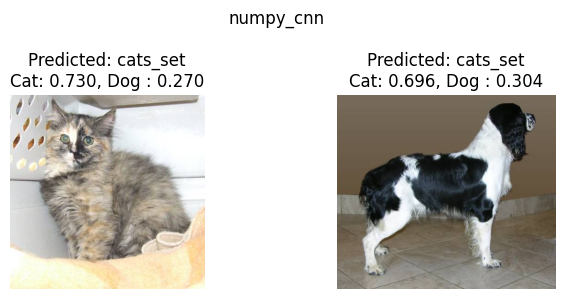

In [152]:
check_model(cat_img, dog_img, model_np, 'numpy_cnn')

----------forward---------
Conv2d_layer (1, 1, 16, 16)
ReLU_layer (1, 4, 16, 16)
MaxPool2D_layer (1, 4, 16, 16)


100%|██████████| 4/4 [00:00<00:00, 8503.40it/s]



Flatten_layer (1, 4, 8, 8)
Linear_layer (1, 256)
ReLU_layer (1, 16)
Linear_layer (1, 16)
Flatten_layer (1, 2)
Softmax_layer (1, 2)
----------forward---------
Conv2d_layer (1, 1, 16, 16)
ReLU_layer (1, 4, 16, 16)
MaxPool2D_layer (1, 4, 16, 16)


100%|██████████| 4/4 [00:00<00:00, 12975.42it/s]


Flatten_layer (1, 4, 8, 8)
Linear_layer (1, 256)
ReLU_layer (1, 16)
Linear_layer (1, 16)
Flatten_layer (1, 2)
Softmax_layer (1, 2)


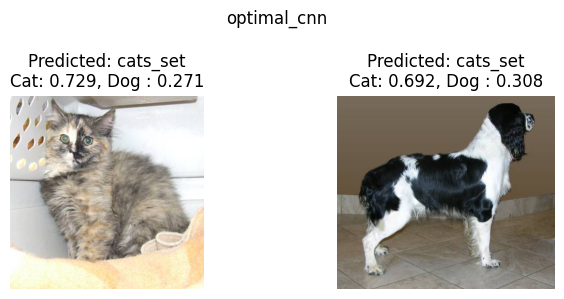

In [153]:
check_model(cat_img, dog_img, model_opt, 'optimal_cnn')

По результатам Выполненной работы, с помощью numba получилось ускорить обучение в 8 раз (178 сек > 23 сек, на numpy и numba соответственно)

Результаты обученных моделей совпадают, но точность результатов всегда перевешивает в сторону класса с кошками